# Randomization Methods - Bootstrapping the Sampling Distribution - White's Reality Check

> **L’Eurêka final :** Le **White's Reality Check** ne demande pas : “est-ce que ma meilleure stratégie semble bonne ?”  
> Il demande : “est-ce que ma meilleure stratégie est meilleure que ce que le hasard peut produire quand il a le droit de tester autant de stratégies que moi ?”

Ce notebook explique le **White's Reality Check** dans l'esprit EBTA : transformer une intuition de trading en test statistique rigoureux.

Nous allons construire une simulation simple en Python pour comprendre :

- pourquoi le meilleur backtest parmi $N$ règles est naturellement biaisé ;
- pourquoi un test classique sur une seule règle est insuffisant ;
- comment le **zéro-centrage** force l'hypothèse nulle $H_0$ ;
- comment le bootstrap par dates conserve la dépendance transversale entre règles ;
- comment obtenir une **p-value WRC**.


## 1. Le problème : le meilleur backtest est contaminé par la sélection

Quand tu testes une seule règle de trading, tu peux poser une question simple :

> “Quelle est la probabilité qu'une règle sans edge obtienne ce résultat par hasard ?”

Mais quand tu testes $N$ règles, la question change complètement :

> “Quelle est la probabilité que la **meilleure règle parmi $N$ règles sans edge** obtienne ce résultat par hasard ?”

Ce changement est fondamental.

Si tu testes 1 000 variantes de stratégies, même si elles sont toutes inutiles, il est presque certain que l'une d'elles aura une belle equity curve par pur hasard.

C'est le **biais de minage de données**.

| Situation | Question statistique | Risque |
|---|---:|---:|
| Une seule règle testée | Est-ce que cette règle bat zéro ? | Faible |
| 1 000 règles testées | Est-ce que le champion bat ce que le hasard peut produire parmi 1 000 candidats ? | Très élevé |

> Le WRC remplace la distribution d'une règle isolée par la **distribution du maximum**.


## 2. Hypothèse nulle du White's Reality Check

Le WRC teste l'hypothèse suivante :

$$
H_0 : E[r_i] = 0 \quad \text{pour toutes les règles } i = 1, \dots, N
$$

Autrement dit :

> Aucune règle n'a de véritable rendement attendu positif.

Pour simuler cette hypothèse nulle, on prend les rendements historiques de chaque règle et on retire sa moyenne :

$$
\tilde{r}_{t,i} = r_{t,i} - \bar{r}_i
$$

Ainsi, chaque règle conserve sa forme, sa volatilité et ses accidents historiques, mais son rendement moyen devient exactement zéro.

C'est le **zéro-centrage**.

> Le zéro-centrage transforme ton univers réel de stratégies en univers “sans edge”, tout en gardant la structure empirique des rendements.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

# Paramètres de simulation
T = 750          # nombre de jours de backtest, environ 3 ans de trading
N = 200          # nombre de règles testées
B = 2000         # nombre de bootstraps WRC

print(f"Nombre d'observations T = {T}")
print(f"Nombre de règles testées N = {N}")
print(f"Nombre de bootstraps B = {B}")

Nombre d'observations T = 750
Nombre de règles testées N = 200
Nombre de bootstraps B = 2000


## 3. Construire un univers de règles de trading

Pour rendre l'exemple parlant, on simule $N = 200$ règles.

La plupart sont inutiles, mais quelques règles ont un petit edge réel. Cela correspond mieux à une recherche quantitative réaliste : dans un univers de stratégies, certaines idées peuvent avoir un mérite, mais le backtest brut mélange **mérite réel** et **chance statistique**.

Nous allons créer :

- 195 règles sans edge ;
- 5 règles avec un petit edge positif ;
- une corrélation commune entre les règles, comme dans un vrai univers de stratégies proches.


In [2]:
# Facteur commun de marché ou de régime
common_factor = rng.normal(0, 0.006, size=(T, 1))

# Bruit idiosyncratique propre à chaque règle
idiosyncratic_noise = rng.normal(0, 0.010, size=(T, N))

# Petits edges réels uniquement sur quelques règles
true_edges = np.zeros(N)
true_edges[:5] = [0.00035, 0.00030, 0.00025, 0.00020, 0.00015]

# Rendements journaliers simulés des règles
returns = true_edges + common_factor + idiosyncratic_noise

dates = pd.date_range("2020-01-01", periods=T, freq="B")
columns = [f"rule_{i+1:03d}" for i in range(N)]
returns_df = pd.DataFrame(returns, index=dates, columns=columns)

returns_df.head()

,rule_001,rule_002,rule_003,rule_004,rule_005,rule_006,rule_007,rule_008,rule_009,rule_010,...,rule_191,rule_192,rule_193,rule_194,rule_195,rule_196,rule_197,rule_198,rule_199,rule_200
2020-01-01,0.002293,-0.000864,-0.008072,0.022516,0.019830,0.013189,-0.007380,0.010378,0.008225,0.006254,...,0.003944,0.010692,0.006736,0.013831,0.004722,-0.001729,0.005187,-0.027478,0.005657,-0.034656
2020-01-02,-0.023125,-0.001422,-0.001215,-0.017664,-0.013211,0.007466,-0.011080,0.016189,-0.006259,-0.002160,...,0.010948,-0.029436,-0.026255,-0.011672,-0.006095,0.000661,-0.001509,-0.010082,0.003951,0.004062
2020-01-03,0.006693,0.014429,0.007479,-0.000912,0.011631,0.005609,0.004516,0.019232,-0.020006,-0.009674,...,-0.003476,0.008781,0.008893,-0.000764,-0.005821,0.027601,0.007771,-0.002820,0.013662,0.003411
2020-01-06,0.003465,0.011566,-0.007025,0.009370,0.024923,0.010305,0.001881,0.000572,0.001540,0.003104,...,0.003034,0.014043,0.008013,0.004594,0.019282,0.003277,-0.012164,-0.002389,0.011155,0.009598
2020-01-07,-0.027027,-0.018650,-0.017273,-0.015161,-0.025315,-0.017990,-0.018992,-0.003991,-0.003615,-0.013164,...,-0.015593,0.003068,-0.006640,-0.024824,-0.004994,-0.019453,-0.017476,-0.008568,-0.016624,-0.002778


## 4. Sélectionner le champion observé

Dans une démarche de minage de données, on teste toutes les règles et on retient celle qui a la meilleure moyenne historique.

Mathématiquement :

$$
\hat{i} = \arg\max_i \bar{r}_i
$$

Et la performance observée du champion est :

$$
\max_i \bar{r}_i
$$

Le piège est ici : ce maximum est biaisé à la hausse, parce qu'il a été choisi après avoir regardé les données.


In [3]:
mean_returns = returns_df.mean()
best_rule = mean_returns.idxmax()
best_mean_daily = mean_returns.max()
best_mean_annualized = best_mean_daily * 252

summary = pd.DataFrame({
    "best_rule": [best_rule],
    "best_mean_daily": [best_mean_daily],
    "best_mean_annualized": [best_mean_annualized],
})

summary

,best_rule,best_mean_daily,best_mean_annualized
0,rule_152,0.000858,0.216233


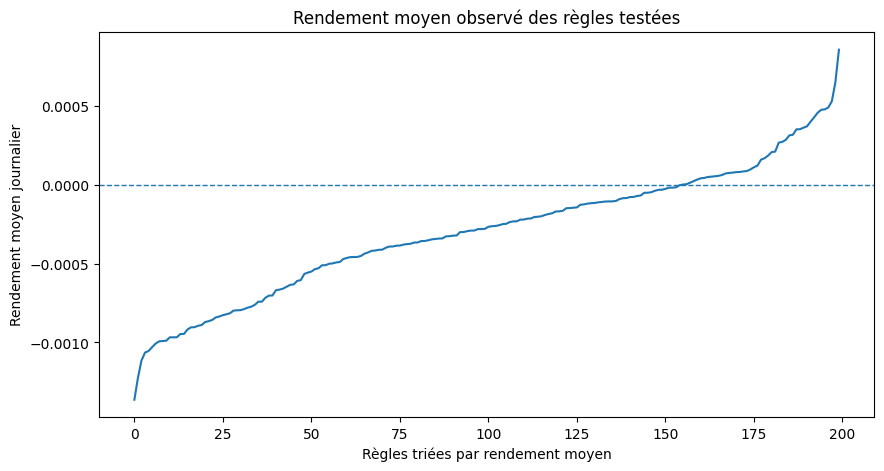

In [4]:
plt.figure(figsize=(10, 5))
mean_returns.sort_values().reset_index(drop=True).plot()
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Rendement moyen observé des règles testées")
plt.xlabel("Règles triées par rendement moyen")
plt.ylabel("Rendement moyen journalier")
plt.show()

## 5. Le test naïf : comparer le champion comme s'il était seul

Un test naïf traite le champion comme si on l'avait choisi avant de regarder les données.

C'est faux dans un contexte de data mining.

La statistique naïve ressemble à ceci :

$$
t = \frac{\bar{r}_{\hat{i}}}{s_{\hat{i}} / \sqrt{T}}
$$

Mais ce test ignore que $N - 1$ autres règles ont été testées puis oubliées.

> Le test naïf pose la mauvaise question : il juge le champion comme une règle isolée, alors qu'il est le survivant d'un tournoi.


In [5]:
best_returns = returns_df[best_rule]
naive_t_stat = best_returns.mean() / (best_returns.std(ddof=1) / np.sqrt(T))

print(f"Meilleure règle observée : {best_rule}")
print(f"Moyenne journalière observée : {best_mean_daily:.6f}")
print(f"Moyenne annualisée observée : {best_mean_annualized:.2%}")
print(f"t-stat naïve : {naive_t_stat:.2f}")

Meilleure règle observée : rule_152
Moyenne journalière observée : 0.000858
Moyenne annualisée observée : 21.62%
t-stat naïve : 2.02


## 6. White's Reality Check : procédure complète

Le WRC suit une logique stricte.

### Étape A — conserver tous les rendements

On garde la matrice complète :

$$
R =
\begin{bmatrix}
r_{1,1} & r_{1,2} & \dots & r_{1,N} \\
r_{2,1} & r_{2,2} & \dots & r_{2,N} \\
\vdots & \vdots & \ddots & \vdots \\
r_{T,1} & r_{T,2} & \dots & r_{T,N}
\end{bmatrix}
$$

Chaque colonne est une règle.

Chaque ligne est une date.

### Étape B — zéro-centrer chaque règle

$$
\tilde{r}_{t,i} = r_{t,i} - \bar{r}_i
$$

### Étape C — bootstrap par dates

On tire des lignes entières de la matrice avec remise.

Cela conserve la relation entre les règles à une date donnée.

### Étape D — prendre le maximum

Pour chaque bootstrap $b$, on calcule :

$$
M_b = \max_i \left( \frac{1}{T} \sum_{t=1}^{T} \tilde{r}^{*b}_{t,i} \right)
$$

La distribution des $M_b$ est la **sampling distribution du meilleur parmi $N$ sous $H_0$**.

### Étape E — p-value WRC

$$
p = \frac{1}{B} \sum_{b=1}^{B} \mathbf{1}(M_b \geq \max_i \bar{r}_i)
$$

Si cette p-value est basse, le champion réel bat ce que le hasard produit normalement dans un tournoi de $N$ règles.


In [6]:
def whites_reality_check(returns_df: pd.DataFrame, n_bootstraps: int = 2000, seed: int = 42):
    """
    Implémentation pédagogique du White's Reality Check.

    Parameters
    ----------
    returns_df:
        DataFrame T x N contenant les rendements de toutes les règles.
    n_bootstraps:
        Nombre de rééchantillonnages bootstrap.
    seed:
        Graine aléatoire pour rendre les résultats reproductibles.

    Returns
    -------
    dict:
        Résultats principaux du WRC.
    """
    rng = np.random.default_rng(seed)

    returns = returns_df.to_numpy()
    T, N = returns.shape

    observed_means = returns.mean(axis=0)
    observed_best_mean = observed_means.max()
    observed_best_idx = observed_means.argmax()

    # Zéro-centrage sous H0
    centered_returns = returns - observed_means

    bootstrap_max_means = np.empty(n_bootstraps)

    for b in range(n_bootstraps):
        sampled_dates = rng.integers(0, T, size=T)

        # On tire des dates entières, donc toutes les règles du même jour restent alignées
        sample = centered_returns[sampled_dates, :]

        sample_means = sample.mean(axis=0)
        bootstrap_max_means[b] = sample_means.max()

    p_value = np.mean(bootstrap_max_means >= observed_best_mean)

    return {
        "observed_best_idx": observed_best_idx,
        "observed_best_name": returns_df.columns[observed_best_idx],
        "observed_best_mean": observed_best_mean,
        "observed_best_annualized": observed_best_mean * 252,
        "bootstrap_max_means": bootstrap_max_means,
        "wrc_p_value": p_value,
    }


wrc = whites_reality_check(returns_df, n_bootstraps=B, seed=123)

print(f"Champion observé : {wrc['observed_best_name']}")
print(f"Moyenne journalière du champion : {wrc['observed_best_mean']:.6f}")
print(f"Moyenne annualisée du champion : {wrc['observed_best_annualized']:.2%}")
print(f"P-value WRC : {wrc['wrc_p_value']:.4f}")

Champion observé : rule_152
Moyenne journalière du champion : 0.000858
Moyenne annualisée du champion : 21.62%
P-value WRC : 0.7200


## 7. Visualiser la distribution du maximum

La distribution ci-dessous représente ce que le hasard peut produire quand il a le droit de tester $N$ règles sans edge et de choisir la meilleure.

La ligne verticale représente le champion réellement observé.

Interprétation :

- si la ligne est au cœur de la distribution, le champion est banal ;
- si la ligne est très à droite, le champion est difficile à expliquer par le hasard ;
- la p-value mesure la proportion de simulations situées à droite de cette ligne.


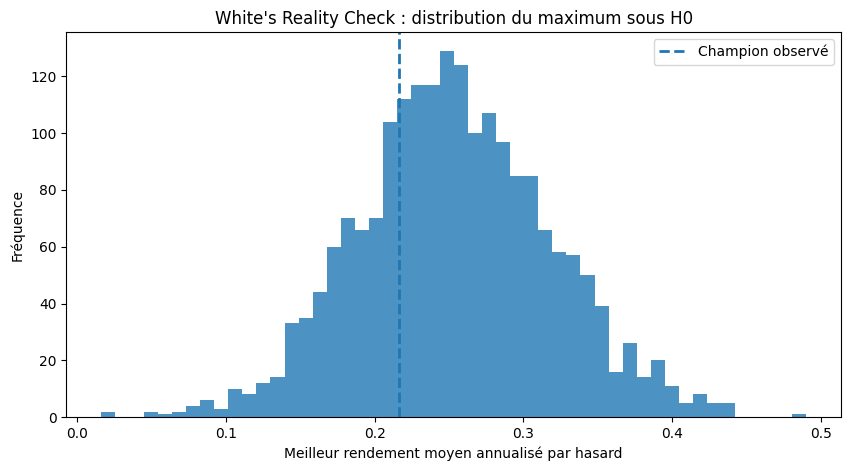

P-value WRC : 0.7200


In [7]:
bootstrap_max_means = wrc["bootstrap_max_means"]
observed_best_mean = wrc["observed_best_mean"]

plt.figure(figsize=(10, 5))
plt.hist(bootstrap_max_means * 252, bins=50, alpha=0.8)
plt.axvline(observed_best_mean * 252, linestyle="--", linewidth=2, label="Champion observé")
plt.title("White's Reality Check : distribution du maximum sous H0")
plt.xlabel("Meilleur rendement moyen annualisé par hasard")
plt.ylabel("Fréquence")
plt.legend()
plt.show()

print(f"P-value WRC : {wrc['wrc_p_value']:.4f}")

## 8. Comparaison : bootstrap classique vs WRC

Un bootstrap classique pourrait tester uniquement le champion.

Le WRC teste le champion contre le **meilleur hasard possible parmi $N$ règles**.

| Méthode | Distribution utilisée | Corrige le data mining ? |
|---|---:|---:|
| Test naïf | Une règle isolée | Non |
| Bootstrap classique | Le champion comme s'il était pré-sélectionné | Non |
| White's Reality Check | Maximum parmi $N$ règles sans edge | Oui |

> Le WRC n'est pas plus sévère par pessimisme. Il est plus sévère parce qu'il pose la question statistiquement correcte.


In [8]:
def naive_bootstrap_single_rule(rule_returns: pd.Series, n_bootstraps: int = 2000, seed: int = 123):
    rng = np.random.default_rng(seed)

    x = rule_returns.to_numpy()
    T = len(x)

    observed_mean = x.mean()
    centered = x - observed_mean

    bootstrap_means = np.empty(n_bootstraps)

    for b in range(n_bootstraps):
        sample_idx = rng.integers(0, T, size=T)
        bootstrap_means[b] = centered[sample_idx].mean()

    p_value = np.mean(bootstrap_means >= observed_mean)

    return bootstrap_means, p_value


naive_boot_means, naive_p_value = naive_bootstrap_single_rule(returns_df[wrc["observed_best_name"]], B)

comparison = pd.DataFrame({
    "Méthode": ["Bootstrap naïf sur le champion", "White's Reality Check"],
    "Question posée": [
        "Cette règle isolée pourrait-elle faire ce score par hasard ?",
        "Le meilleur parmi N règles sans edge pourrait-il faire ce score par hasard ?"
    ],
    "P-value": [naive_p_value, wrc["wrc_p_value"]],
})

comparison

,Méthode,Question posée,P-value
0,Bootstrap naïf sur le champion,Cette règle isolée pourrait-elle faire ce scor...,0.017
1,White's Reality Check,Le meilleur parmi N règles sans edge pourrait-...,0.720


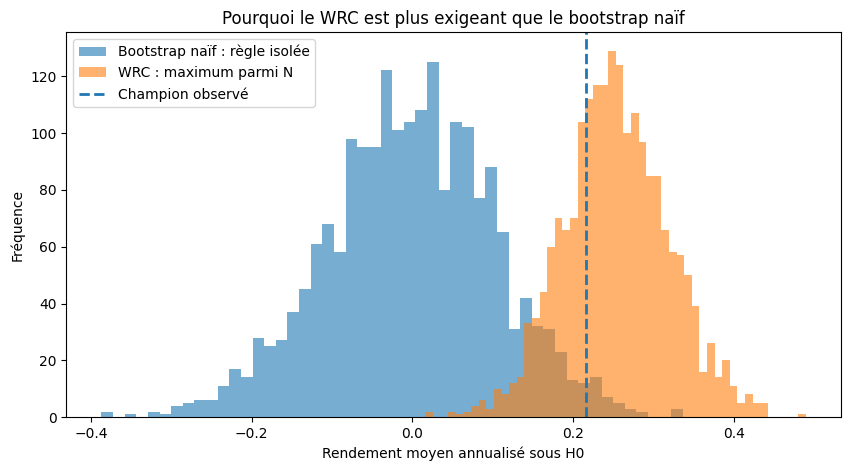

In [9]:
plt.figure(figsize=(10, 5))
plt.hist(naive_boot_means * 252, bins=50, alpha=0.6, label="Bootstrap naïf : règle isolée")
plt.hist(bootstrap_max_means * 252, bins=50, alpha=0.6, label="WRC : maximum parmi N")
plt.axvline(observed_best_mean * 252, linestyle="--", linewidth=2, label="Champion observé")
plt.title("Pourquoi le WRC est plus exigeant que le bootstrap naïf")
plt.xlabel("Rendement moyen annualisé sous H0")
plt.ylabel("Fréquence")
plt.legend()
plt.show()

## 9. Lecture trading : ce que le WRC change dans ton process

Le WRC force une discipline de recherche.

### Avant WRC

Tu peux tester 500 variantes :

- filtres horaires ;
- tailles de stop ;
- ratios risk/reward ;
- conditions de trend ;
- seuils d'indicateurs ;
- variantes ICT ou engulfing.

Puis tu gardes le meilleur backtest.

Le danger : tu crois avoir trouvé un edge, mais tu as peut-être seulement trouvé le gagnant d'une loterie statistique.

### Après WRC

Tu dois conserver les rendements de toutes les variantes testées.

Ensuite, tu demandes :

> “Mon champion bat-il la performance typique du champion chanceux parmi autant de variantes inutiles ?”

C'est exactement le genre de garde-fou qu'il faut pour un projet EBTA sérieux.

| Élément du process | Sans WRC | Avec WRC |
|---|---:|---:|
| Règles perdantes | Souvent oubliées | Conservées |
| Meilleur backtest | Pris au sérieux trop vite | Comparé au hasard maximum |
| P-value | Trop optimiste | Corrigée pour comparaisons multiples |
| Décision | Risque de sur-optimisation | Validation plus scientifique |


## 10. Pseudo-code opérationnel pour tes backtests

Voici la version process à intégrer dans une recherche de stratégies.

```text
1. Définir l'univers de règles à tester
2. Backtester chaque règle sur la même période
3. Sauvegarder les rendements périodiques de chaque règle
4. Identifier la meilleure règle observée
5. Zéro-centrer chaque colonne de rendements
6. Répéter B fois :
   a. Tirer T dates avec remise
   b. Récupérer les rendements de toutes les règles sur ces dates
   c. Calculer la moyenne de chaque règle
   d. Stocker la meilleure moyenne
7. Calculer la p-value :
   p = proportion des maximums bootstrappés >= performance du champion observé
8. Interpréter :
   - p faible : edge potentiellement réel
   - p élevé : champion probablement chanceux
```

> Le point non négociable : tu dois sauvegarder les rendements de **toutes** les règles testées.


## 11. Limites importantes du WRC

Le WRC est puissant, mais il n'est pas magique.

### Limite 1 — Dépendance temporelle

Le bootstrap par dates simple peut casser certaines dépendances temporelles.

Pour des rendements très autocorrélés, on peut préférer un **block bootstrap**, qui tire des blocs de dates consécutives plutôt que des journées isolées.

### Limite 2 — Univers mal défini

Si tu testes 200 règles aujourd'hui, puis 300 demain, puis 100 encore après, mais que tu ne gardes pas l'historique complet de cette recherche, la correction devient incomplète.

### Limite 3 — P-value élevée ne prouve pas l'absence totale d'edge

Une p-value élevée signifie surtout :

> Les données disponibles ne suffisent pas à distinguer ton champion de ce que le hasard peut produire dans ton univers de recherche.

Ce n'est pas la même chose que prouver définitivement que la règle est inutile.


## 12. Eurêka final

> **Le White's Reality Check est une simulation de tournoi contre le hasard.**

Le trader ne demande plus :

> “Est-ce que ma meilleure stratégie gagne de l'argent dans le backtest ?”

Il demande :

> “Est-ce que ma meilleure stratégie gagne plus que le meilleur imposteur statistique que le hasard peut produire après avoir testé autant de règles que moi ?”

C'est ce changement de question qui rend le WRC indispensable dans une démarche **Evidence-Based Technical Analysis**.

Une stratégie peut être profitable en backtest et pourtant échouer au WRC.

Dans ce cas, le message est clair :

> Le profit observé n'est pas encore une preuve d'edge. C'est peut-être seulement le bruit qui a gagné la compétition.


## 13. Checklist EBTA pour appliquer le WRC à tes propres stratégies

| Question | Réponse attendue |
|---|---|
| Ai-je conservé les rendements de toutes les règles testées ? | Oui |
| Toutes les règles sont-elles testées sur la même période ? | Oui |
| Ai-je zéro-centré chaque règle séparément ? | Oui |
| Le bootstrap tire-t-il des dates entières, pas des cellules isolées ? | Oui |
| Est-ce que je compare mon champion à la distribution du maximum ? | Oui |
| Est-ce que ma p-value est corrigée pour l'intensité de recherche ? | Oui |

> Si tu ne sauvegardes que le gagnant, tu ne peux pas faire un vrai White's Reality Check.


## 14. Mini-template pour intégrer le WRC dans un pipeline de backtest

La structure attendue est une matrice de rendements :

```python
returns_df
```

où :

- les lignes sont les dates ;
- les colonnes sont les règles ;
- les valeurs sont les rendements périodiques.

Exemple :

| date | rule_001 | rule_002 | rule_003 |
|---|---:|---:|---:|
| 2024-01-01 | 0.001 | -0.002 | 0.000 |
| 2024-01-02 | -0.001 | 0.001 | 0.003 |
| 2024-01-03 | 0.002 | 0.000 | -0.001 |

Ensuite, tu peux appeler :

```python
wrc = whites_reality_check(returns_df, n_bootstraps=5000)
```

et lire :

```python
wrc["wrc_p_value"]
```


In [10]:
# Exemple de fonction compacte à réutiliser dans un vrai projet EBTA

def ebta_wrc_p_value(returns_df, n_bootstraps=5000, seed=42):
    rng = np.random.default_rng(seed)

    returns = returns_df.to_numpy()
    T, N = returns.shape

    observed_means = returns.mean(axis=0)
    observed_max = observed_means.max()

    centered = returns - observed_means

    max_under_null = []

    for _ in range(n_bootstraps):
        idx = rng.integers(0, T, T)
        boot_sample = centered[idx, :]
        max_under_null.append(boot_sample.mean(axis=0).max())

    max_under_null = np.array(max_under_null)
    p_value = np.mean(max_under_null >= observed_max)

    return p_value, observed_max, max_under_null


p_value, observed_max, max_under_null = ebta_wrc_p_value(returns_df, n_bootstraps=2000)

print(f"P-value WRC compacte : {p_value:.4f}")
print(f"Rendement journalier moyen du champion : {observed_max:.6f}")

P-value WRC compacte : 0.7230
Rendement journalier moyen du champion : 0.000858


## Annexe — Texte source fourni

Le texte ci-dessous est conservé comme annexe, conformément au protocole `/codeexemple`.


### **RANDOMIZATION METHODS - BOOTSTRAPPING THE SAMPLING DISTRIBUTION: WHITE'S REALITY CHECK**

Cette section détaille l'utilisation des méthodes de randomization, et plus particulièrement du *White's Reality Check* (WRC), pour évaluer la validité d'une règle découverte par minage de données sans avoir à sacrifier des données historiques pour des tests hors-échantillon.

#### **Idées clés :**
*   **Utilisation intégrale de l'historique :** Le WRC permet d'utiliser 100 % des données disponibles pour le minage tout en corrigeant statistiquement le biais de sélection.
*   **Correction pour comparaisons multiples :** Contrairement au bootstrap classique, le WRC est conçu pour évaluer la significativité du *meilleur* candidat parmi $N$ règles testées.
*   **La distribution du maximum :** Le WRC construit une distribution de probabilité pour le rendement maximum que le pur hasard peut générer au sein d'un univers de règles sans valeur.
*   **Nécessité de conservation des données :** Pour être appliqué, le WRC exige de conserver l'historique des rendements de *toutes* les règles examinées, pas seulement celui du gagnant.

#### **Référence :**
*Randomization Methods - Bootstrapping the Sampling Distribution: White's Reality Check*, Chapitre 6, pages 324 à 327.

#### **Citation Directe :**
« Specifically, WRC permits the data miner to develop the sampling distribution for the best of N-rules, where N is the number of rules tested, under the assumption that all of the rules have expected returns of zero. ».

---

#### **Vision Macro :**
L'enjeu est l'efficacité de la recherche. David Aronson explique que la segmentation des données (In-Sample / Out-of-Sample) est une protection coûteuse car elle réduit la taille de l'échantillon disponible pour l'apprentissage. Le WRC offre une alternative scientifique : il utilise la puissance de calcul pour simuler des milliers de « compétitions de chance » entre des règles inutiles. Si le profit de votre règle réelle est supérieur à ce que le hasard produit dans ces simulations, alors vous avez identifié un avantage prédictif légitime plutôt que du « métal des fous ».

---

#### **Vision Micro :**
Le mécanisme technique du WRC repose sur une procédure de rééchantillonnage rigoureuse :

1.  **L'Univers de Référence :** On part d'un ensemble de $N$ règles testées sur une période historique.
2.  **Le Zéro-Centrage (Étape Cruciale) :** Pour simuler l'Hypothèse Nulle ($H_0$), on soustrait le rendement moyen de chaque règle de ses rendements quotidiens respectifs. Ainsi, chaque règle de l'univers a désormais un mérite réel de zéro.
3.  **Le Bootstrapping par Dates :**
    *   On place toutes les dates de la période de test dans un « seau ».
    *   On tire au sort une date avec remise, et on note les rendements de *toutes* les règles pour ce jour précis.
    *   On répète l'opération jusqu'à obtenir un historique de longueur identique à l'original.
4.  **La Sélection du Champion Chanceux :** On calcule la moyenne de rendement de chaque règle sur cet échantillon artificiel et on ne conserve que la valeur de la **meilleure moyenne** ($Maximum Mean$).
5.  **Construction de la Distribution :** En répétant ces étapes des milliers de fois (ex: 500 ou plus), on obtient une distribution de probabilité du meilleur profit possible par pur hasard parmi $N$ règles.
6.  **Calcul de la P-Value :** La p-value est la fraction de ces « records chanceux » qui sont égaux ou supérieurs au profit réellement observé sur votre backtest.

---

#### **Résumé Simplifié :**
Le WRC est un simulateur de « chance olympique ». Si vous avez testé 1 000 stratégies, l'ordinateur va simuler 1 000 stratégies idiotes et regarder quel est le meilleur score que la chance pure peut obtenir dans un tel groupe. Il répète cette simulation des milliers de fois pour créer une échelle de mesure du hasard. Si votre stratégie bat le record de chance de l'ordinateur, elle est validée.

---

#### **Actions Concrètes :**
*   **Sauvegarder tous les rendements :** Ne jetez pas les résultats des règles qui ont échoué ; le WRC a besoin des rendements quotidiens de l'intégralité de votre univers de recherche ($N$) pour évaluer le biais.
*   **Utiliser un logiciel spécialisé :** L'application du WRC est complexe ; Aronson mentionne le logiciel « Forecaster's Reality Check » pour automatiser ces calculs.
*   **Comparer à la distribution du maximum :** Ne comparez jamais votre champion à une distribution de règle unique. Utilisez systématiquement la distribution du *maximum* pour tenir compte de l'intensité de votre recherche.

---

#### **À retenir absolument :**
*   Le WRC corrige le biais de minage **sans gaspiller de données**.
*   Il repose sur le **zéro-centrage** des rendements pour forcer l'hypothèse nulle.
*   Il modélise la performance du **meilleur parmi N**, et non d'une règle isolée.
*   C'est l'outil standard de l'EBTA pour valider les recherches **intensives**.
*   Une p-value élevée au WRC signifie que votre profit est un **artefact statistique**.

J'ai terminé l'analyse du White's Reality Check selon le protocole EBTA.
